In [2]:
import os
import timm
import torch
import numpy as np
import pandas as pd
import torch.nn as nn
from tqdm import tqdm
import torch.optim as optim
import matplotlib.pyplot as plt
from torchvision import transforms
import torch.nn.functional as nnf
from torch.utils.data import Dataset, DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score, precision_score, recall_score, confusion_matrix, roc_curve, auc, roc_auc_score
from torchvision import models
import torchvision

In [3]:
RANDOM_SEED = 42
IMG_SIZE = 224
BATCH_SIZE = 16
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4
NUM_EPOCHS = 10
NUM_CLASSES = 3
MODEL_PATH = 'resnet_50_best.pth'

In [4]:
train_dir='dataset/train'
val_dir='dataset/val'

In [6]:
device=('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [7]:
train_imgs = sorted([
    pth for pth in os.listdir(train_dir)
    if os.path.isdir(os.path.join(train_dir, pth))
])
val_imgs = sorted([
    pth for pth in os.listdir(val_dir)
    if os.path.isdir(os.path.join(val_dir, pth))
])


In [8]:
train_temp=[]
val_temp=[]

In [9]:
for pth in train_imgs:
    path = os.path.join(train_dir, pth)
    train_temp.append(path)


In [10]:
for pth in val_imgs:
    path = os.path.join(val_dir, pth)
    val_temp.append(path)


In [11]:
train_temp


['dataset/train/no', 'dataset/train/sphere', 'dataset/train/vort']

In [12]:
train_img_path=[]
train_class=[]
val_img_path=[]
val_class=[]

In [13]:
CLASS_NAMES = ['no', 'sphere', 'vort']
CLASS_TO_IDX = {label: idx for idx, label in enumerate(CLASS_NAMES)}


def class_def(label):
    return CLASS_TO_IDX[label]


In [14]:
for el in train_temp:
    label_name = os.path.basename(el)
    for it in sorted(os.listdir(el)):
        p = os.path.join(el, it)
        if os.path.isfile(p):
            train_img_path.append(p)
            train_class.append(class_def(label_name))


In [15]:
for el in val_temp:
    label_name = os.path.basename(el)
    for it in sorted(os.listdir(el)):
        p = os.path.join(el, it)
        if os.path.isfile(p):
            val_img_path.append(p)
            val_class.append(class_def(label_name))


In [16]:
train_img_path, test_img_path, train_class, test_class = train_test_split(
    train_img_path,
    train_class,
    test_size=0.1,
    shuffle=True,
    random_state=RANDOM_SEED,
    stratify=train_class,
)


In [18]:
print("Train Size: ", len(train_img_path))
print("Test Size: ", len(test_img_path))
print("Val Size: ", len(val_img_path))

Train Size:  27000
Test Size:  3000
Val Size:  7500


In [19]:
class MyDataset(Dataset):
    def __init__(self, img_path, transform):
        self.img_path = img_path
        self.transform = transform

    def __len__(self):
        return len(self.img_path)

    def __getitem__(self, idx):
        image_path = self.img_path[idx]
        img = np.load(image_path).astype(np.float32)
        img = torch.from_numpy(img)
        if self.transform:
            img = self.transform(img)
        label = os.path.basename(os.path.dirname(image_path))
        label = class_def(label)
        return img, label


In [20]:
def transform(split):
    transforms_list = []
    
    transforms_list.append(transforms.Resize((224, 224)))
    
    if split == 'train':
        transforms_list.append(transforms.RandomHorizontalFlip(p=0.5))
    
    transforms_list.append(transforms.Normalize(mean=[0.449], std=[0.226]))
    return transforms.Compose(transforms_list)

In [21]:
train_transform = transform('train')
val_transform = transform('val')

In [22]:
train_dataset = MyDataset(train_img_path, transform=train_transform)
test_dataset = MyDataset(test_img_path, transform=val_transform)
val_dataset = MyDataset(val_img_path, transform=val_transform)


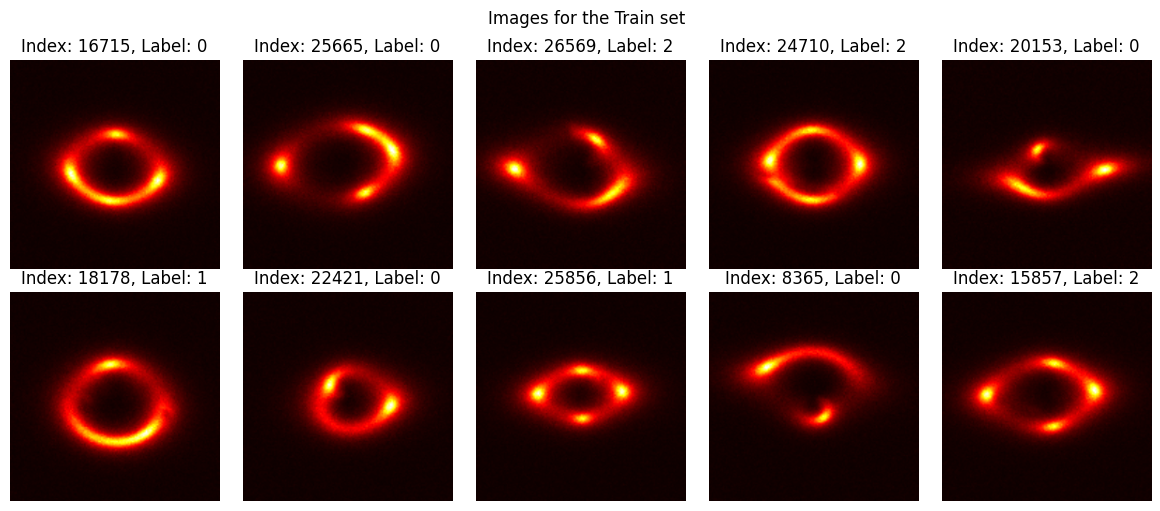

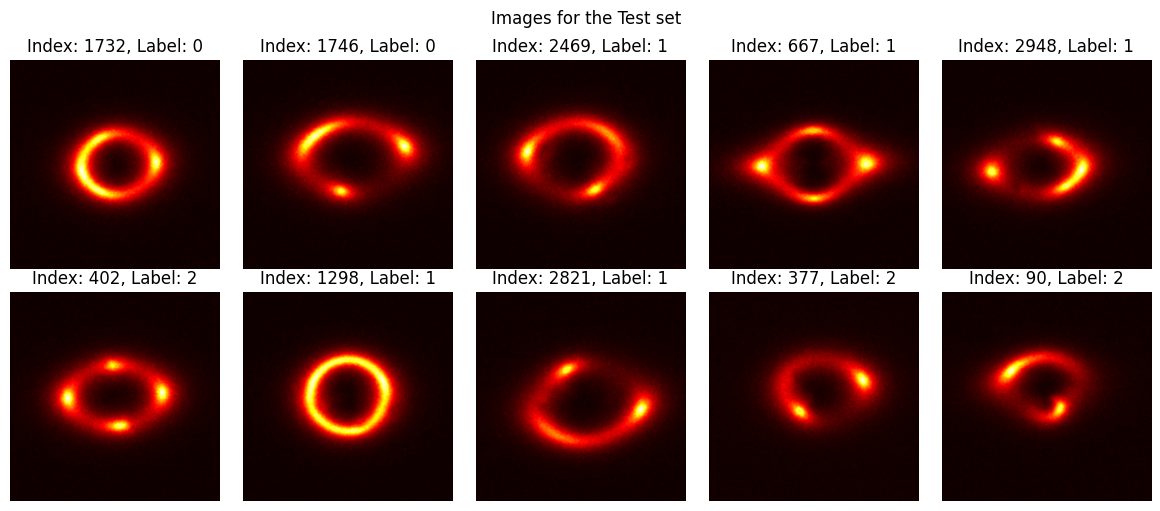

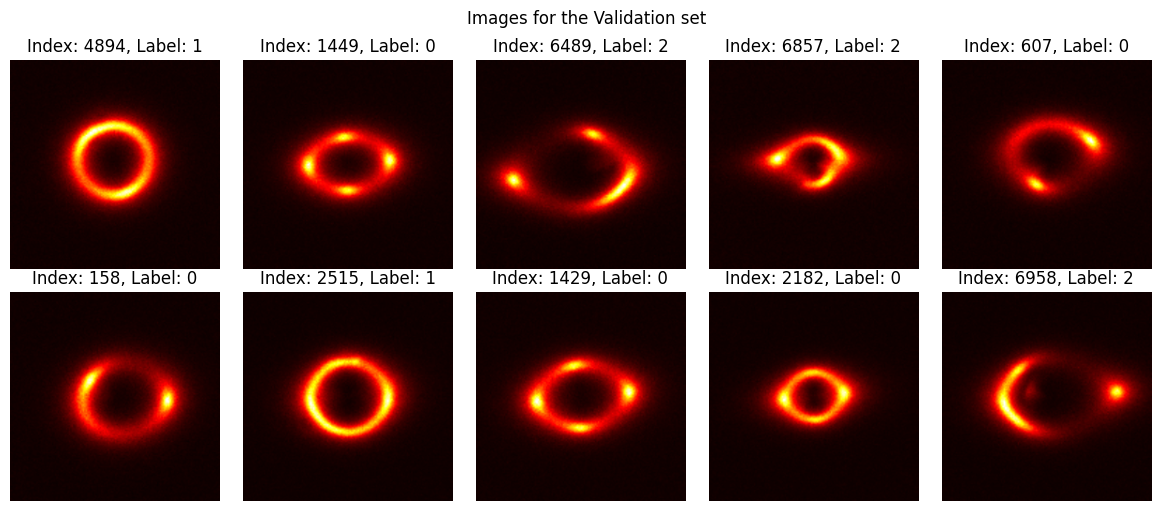

In [23]:
def visualize_images(dataset_input, dataset_type, samples, cols):
    
    dataset_len = len(dataset_input)
    dataset = dataset_input
    
    rows = samples // cols
    
    fig, ax = plt.subplots(nrows = rows, ncols = cols, figsize=(12, 8))
    fig.suptitle(f"Images for the {dataset_type.title()} set", y=0.9)
    
    for i in range(samples):
        idx = np.random.randint(0, dataset_len)
        image, label = dataset[idx]
        image = image.swapaxes(0, 1)
        image = image.swapaxes(1, 2)
        ax.ravel()[i].imshow(image, cmap='hot')
        ax.ravel()[i].set_axis_off()
        ax.ravel()[i].set_title(f"Index: {idx}, Label: {label}")
        
    plt.tight_layout(rect=[0, 0.2, 0.99, 0.975], h_pad=2.1, pad=1.7)
    plt.show()
    
visualize_images(dataset_input=train_dataset, dataset_type="train", samples=10, cols=5)
visualize_images(dataset_input=test_dataset, dataset_type="test", samples=10, cols=5)
visualize_images(dataset_input=val_dataset, dataset_type="validation", samples=10, cols=5)

In [24]:
def MyDataloader(dataset, shuffle):
    loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=shuffle)
    return loader

In [25]:
train_loader = MyDataloader(dataset=train_dataset, shuffle=True)
test_loader = MyDataloader(dataset=test_dataset, shuffle=False)
val_loader = MyDataloader(dataset=val_dataset, shuffle=False)


In [26]:
class Model(nn.Module):
    
    def __init__(self, num_classes, pretrained=True):
        super().__init__()

        weights = None
        if pretrained:
            weights = torchvision.models.ResNet50_Weights.DEFAULT

        self.backbone = torchvision.models.resnet50(weights=weights)

        original_conv = self.backbone.conv1
        self.backbone.conv1 = nn.Conv2d(
            in_channels=1,
            out_channels=original_conv.out_channels,
            kernel_size=original_conv.kernel_size,
            stride=original_conv.stride,
            padding=original_conv.padding,
            bias=False,
        )
        if pretrained:
            with torch.no_grad():
                self.backbone.conv1.weight.copy_(original_conv.weight.mean(dim=1, keepdim=True))

        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Linear(in_features, num_classes)

    def forward(self, x):
        return self.backbone(x)

In [28]:
model=Model(num_classes = NUM_CLASSES, pretrained=True).to(device)

In [29]:
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=2,
)

In [30]:
best_test_accuracy = 0.0

for ep in range(NUM_EPOCHS):
    model.train()
    print(f'Epoch No.: {ep + 1}')
    total = 0
    correct = 0
    running_loss = 0.0

    progress_bar = tqdm(train_loader, desc='Train', leave=False)
    for img, lab in progress_bar:
        img = img.to(device)
        lab = lab.to(device)

        optimizer.zero_grad()
        y_pred = model(img.float())
        loss = criterion(y_pred, lab)
        loss.backward()
        optimizer.step()

        _, predicted = torch.max(y_pred.data, 1)
        batch_size = lab.size(0)
        total += batch_size
        correct += (predicted == lab).sum().item()
        running_loss += loss.item() * batch_size

        progress_bar.set_postfix(
            loss=f'{running_loss / total:.4f}',
            acc=f'{correct / total:.4f}',
        )

    model.eval()
    val_total = 0
    val_correct = 0
    val_loss = 0.0
    with torch.no_grad():
        for img, lab in tqdm(test_loader, desc='Test', leave=False):
            img = img.to(device)
            lab = lab.to(device)
            y_pred = model(img.float())
            loss = criterion(y_pred, lab)
            _, predicted = torch.max(y_pred.data, 1)

            batch_size = lab.size(0)
            val_total += batch_size
            val_correct += (predicted == lab).sum().item()
            val_loss += loss.item() * batch_size

    avg_train_loss = running_loss / total
    avg_train_acc = correct / total
    avg_test_loss = val_loss / val_total
    avg_test_acc = val_correct / val_total
    scheduler.step(avg_test_loss)

    print(
        f'Train Loss: {avg_train_loss:.4f} '
        f'Train Acc: {avg_train_acc:.4f} '
        f'Test Loss: {avg_test_loss:.4f} '
        f'Test Acc: {avg_test_acc:.4f} '
        f'LR: {optimizer.param_groups[0]["lr"]:.6f}'
    )

    if avg_test_acc > best_test_accuracy:
        best_test_accuracy = avg_test_acc
        torch.save(model.state_dict(), MODEL_PATH)

print(f'Best Test Accuracy: {best_test_accuracy:.4f}')


Epoch No.: 1


Train Loss: 0.8312 Train Acc: 0.5849 Test Loss: 0.4998 Test Acc: 0.7970 LR: 0.000100
Epoch No.: 2


Train Loss: 0.3947 Train Acc: 0.8489 Test Loss: 0.3235 Test Acc: 0.8750 LR: 0.000100
Epoch No.: 3


Train Loss: 0.2922 Train Acc: 0.8906 Test Loss: 0.2693 Test Acc: 0.8997 LR: 0.000100
Epoch No.: 4


Train Loss: 0.2398 Train Acc: 0.9115 Test Loss: 0.2395 Test Acc: 0.9117 LR: 0.000100
Epoch No.: 5


...

Train Loss: 0.1832 Train Acc: 0.9359 Test Loss: 0.2112 Test Acc: 0.9197 LR: 0.000100
Epoch No.: 7


Train Loss: 0.1642 Train Acc: 0.9433 Test Loss: 0.2134 Test Acc: 0.9267 LR: 0.000100
Epoch No.: 8


Train Loss: 0.1501 Train Acc: 0.9456 Test Loss: 0.2073 Test Acc: 0.9257 LR: 0.000100
Epoch No.: 9


Train Loss: 0.1394 Train Acc: 0.9517 Test Loss: 0.2614 Test Acc: 0.9103 LR: 0.000100
Epoch No.: 10


Train Loss: 0.1248 Train Acc: 0.9561 Test Loss: 0.2206 Test Acc: 0.9177 LR: 0.000100
Best Test Accuracy: 0.9267


In [31]:
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.eval()
total = 0
correct = 0
y_test_all = []
y_pred_all = []
y_pred_prob_all = []
with torch.no_grad():
    for img, lab in tqdm(test_loader, desc='Test', leave=False):
        img = img.to(device)
        lab = lab.to(device)
        y_pred = model(img.float())
        prob = nnf.softmax(y_pred, dim=1)
        _, predicted = torch.max(y_pred.data, 1)

        y_test_all.append(lab.cpu())
        y_pred_prob_all.append(prob.cpu())
        y_pred_all.append(predicted.cpu())
        total += lab.size(0)
        correct += (predicted == lab).sum().item()
accuracy = 100 * correct / total
print(f'Test Accuracy is: {accuracy}')


Test Accuracy is: 92.66666666666667


In [32]:
model.eval()
total = 0
correct = 0
y_test_all = []
y_pred_all = []
y_pred_prob_all = []
with torch.no_grad():
    for img, lab in tqdm(val_loader, desc='Val', leave=False):
        img = img.to(device)
        lab = lab.to(device)
        y_pred = model(img.float())
        prob = nnf.softmax(y_pred, dim=1)
        _, predicted = torch.max(y_pred.data, 1)

        y_test_all.append(lab.cpu())
        y_pred_prob_all.append(prob.cpu())
        y_pred_all.append(predicted.cpu())
        total += lab.size(0)
        correct += (predicted == lab).sum().item()
accuracy = 100 * correct / total
print(f'Validation Accuracy is: {accuracy}')


Validation Accuracy is: 92.46666666666667


In [33]:
y_pred = []
y_test = []
for el in y_test_all:
    y_test.extend(el.detach().numpy().tolist())

for el in y_pred_all:
    y_pred.extend(el.detach().numpy().tolist())


In [34]:
y_prob = []
for el in y_pred_prob_all:
    y_prob.extend(el.detach().numpy().tolist())


In [35]:
y_pred=np.array(y_pred)
y_test=np.array(y_test)
y_pred=y_pred.ravel()
y_test=y_test.ravel()

In [36]:
y_prob=np.array(y_prob)

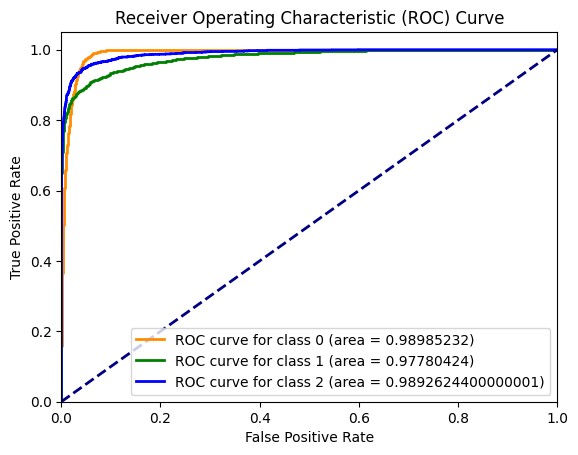

In [37]:
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(3):
    fpr[i], tpr[i], _ = roc_curve((y_test == i), y_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure()
lw = 2
colors = ['darkorange', 'green', 'blue']
for i, color in zip(range(3), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=lw, label=f'ROC curve for class {i} (area = {roc_auc[i]})')
plt.plot([0, 1], [0, 1], color='navy', lw=lw, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

In [38]:
for i in range(3):
    print(f"AUC for class {i}: {roc_auc[i]}")

AUC for class 0: 0.98985232
AUC for class 1: 0.97780424
AUC for class 2: 0.9892624400000001
